## CP Decomposition - normal dispersion example

This example illustrates CP decomposition in the normal dispersion regime, since most of the other notebooks work with anomalous dispersion. The low-rank-ness of the tensor is independent of dispersion, and so as you'll see below, CP works equally well.

In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using Statistics

  Activating project at `~/Desktop/FastDifferentiableMMNLO`


A typical flow is shown below. We start by establishing what the degrees of freedom are and setup a time-grid. We also compute the frequency and wavelength grids, which are useful to have.

In [2]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^13;
time_window = 10; # ps
λ0 = 1030e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);


Now, we need to setup the dispersion and nonlinearity which determine our dynamics. This is done below by establishing the material and fiber system and computing derived properties.

In [3]:
core_radius = 168e-6;
NA = 0.1;
num_modes = 6;
fiber_length = 1;

material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
step_fiber = GRIN(λ0, core_radius, NA);

properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=5)

FiberProperties{TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, AnisotropicRaman{Float64}, FiberModeData{Float64, Float64, Vector{NamedTuple}}, @NamedTuple{profile::Symbol, material::Symbol, lambda0::Float64, core_radius::Float64, NA::Float64, num_modes::Int64, polarization::Symbol, mode_basis::Symbol, beta_order::Int64, dispersion_span::Float64, dispersion_samples::Int64, dispersion_fit_order::Int64, overlap::@NamedTuple{representation::Symbol, quadrature_order::Int64, chunk_points::Int64, max_workspace_bytes::Int64, precision::Symbol, max_tensor_bytes::Nothing}, wavelength_rule::Symbol, grid::@NamedTuple{nx::Int64, ny::Int64, xmin::Float64, xmax::Float64, ymin::Float64, ymax::Float64}}, Float64}(TaylorBeta{Float64, 2}([8.845117586803699e6 8.844707061595865e6 … 8.844296517332705e6 8.844296517332705e6; 4879.073158619415 4879.07513516361 … 4879.077122403596 4879.077122403596; … ; -5.0502140957779285e-8 -5.049053925462462e-8 … -5.051945052037849e-8 -5.051945052037849e-8; 1.5273604535327

Some examples of how you can get property values from properties.

In [4]:
x = y = properties.modes.x
modes = properties.modes.fields; 
betas = properties.beta.coefficients;
S_tensor = properties.S.values;

Taking a peek at the first 3 step-index mode fields.

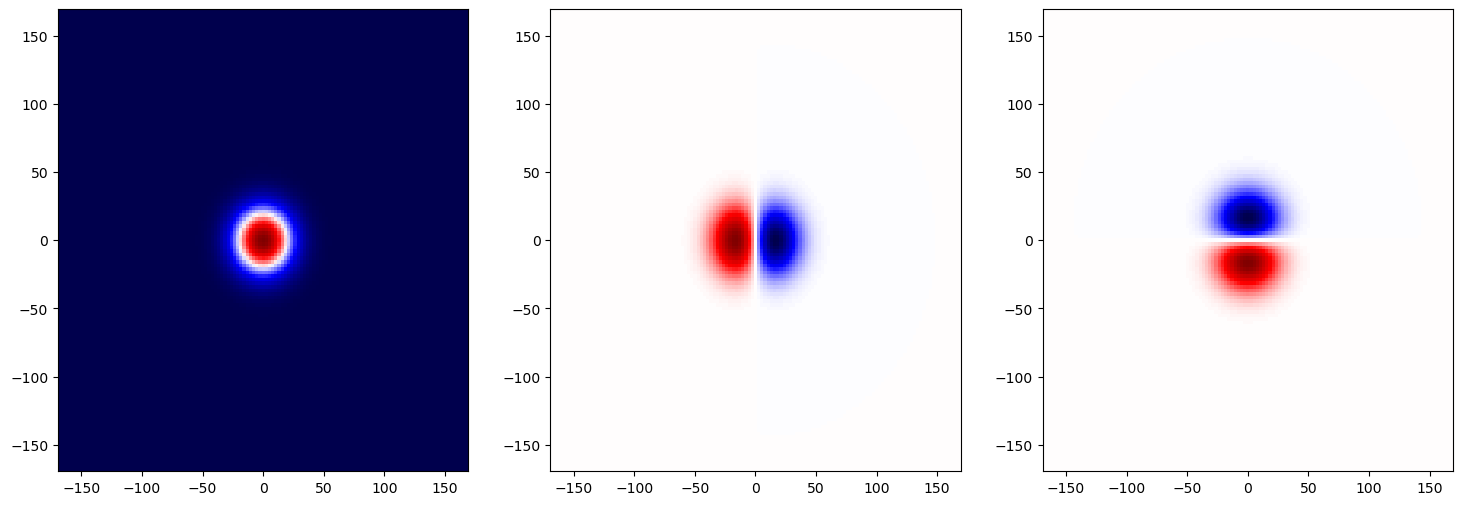

In [5]:
figure(figsize=(18,6))

for ii = 1:3
    subplot(1,3,ii)
    pcolormesh(x*1e6,y*1e6,modes[:,:,ii],cmap="seismic")
end
display(gcf())

We are ready to setup a forward solve. First we set up initial conditions.

In [57]:
peak_power = 50000;
pulse_fwhm = 0.5;

coefficient_vector = ones(num_modes) .* exp.(1im .* randn(num_modes));
coefficient_vector[1] = 1.0;

initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = coefficient_vector
);

The code require us to collect all parameters as follows

In [58]:
parameters = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=properties.S,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, Float64, Float64, AnisotropicRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}, Nothing}(DegreesOfFreedom(:time, :space), TimeGrid{Float64}(8192, 0.001220703125), nothing), 1.0, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([8.845117586803699e6 8.844707061595865e6 … 8.844296517332705e6 8.844296517332705e6; 4879.073158619415 4879.07513516361 … 4879.077122403596 4879.077122403596; … ; -5.0502140957779285e-8 -5.049053925462462e-8 … -5.051945052037849e-8 -5.051945052037849e-8; 1.5273604535327348e-10 1.506245415468805e-10 … 1.516284526852355e-10 1.516284526852355e-10]), SpatialOverlap{Float64}([5.779010633379581e8 3.358962034181432e-8 … 5.52673880060406e-10 2.889505316689792e8; 3.358962034181432e-8 2.889505316689792e8 … -1.7520929306240202e-9 4.9968205128361125e-9; … ; 1.0008534846628762e-9 -1.7520929306240202e-9 … 1.4447526583448955e8 4.481331048

Now we can solve.

In [59]:
dz = 1e-4;
solution = solve_mmgnlse(initial_field, parameters, dz; saveat=0.1);

Visualizing the solution.

In [60]:
At_final = get_temporal_field(solution)
Aomega_final = get_spectral_field(solution)
z_saved = solution.z;

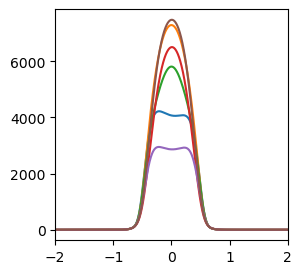

In [61]:
figure(figsize=(3,3))
plot(t,abs2.(At_final[:,:,end]))
xlim(-2,2)
display(gcf())

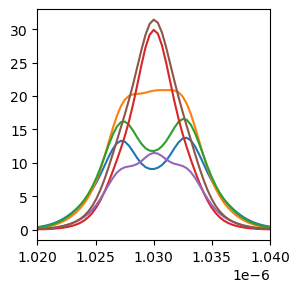

In [62]:
figure(figsize=(3,3))
plot(λ,abs2.(Aomega_final[:,:,1]))
xlim(1020e-9,1040e-9)
display(gcf())

## CP Decomposition

Let us now show that by compressing the four-wave mixing tensor in advance of the calculation, it can be sped up significantly. The added work to do this amounts to compressing the S-tensor and recreating the parameters to incorporate the compressed tensor.

In [78]:
S_compressed_1em1 = cp_compress(properties.S,error=1e-1);
S_compressed_1em3 = cp_compress(properties.S,error=1e-3);

parameters_cp_1em1 = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=S_compressed_1em1,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

parameters_cp_1em3 = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=S_compressed_1em3,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}, Nothing}(DegreesOfFreedom(:time, :space), TimeGrid{Float64}(8192, 0.001220703125), nothing), 1.0, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([8.845117586803699e6 8.844707061595865e6 … 8.844296517332705e6 8.844296517332705e6; 4879.073158619415 4879.07513516361 … 4879.077122403596 4879.077122403596; … ; -5.0502140957779285e-8 -5.049053925462462e-8 … -5.051945052037849e-8 -5.051945052037849e-8; 1.5273604535327348e-10 1.506245415468805e-10 … 1.516284526852355e-10 1.516284526852355e-10]), MMGNLSECPDecomposition{Float64, ComplexF64}([1.81273765027312e9, 1.7958788159450958e9, 7.898334141594211e8, 7.236622599085557e8, 1.8622741452488298e9, 1.846352295334062e9, 1.9193385604432087e9, 7.918456347308207e8, 7.228678130708835e8, 1.7498320914977643e9, 1.93

In [79]:
dz = 1e-4;

solution_cp_1em1 = solve_mmgnlse(initial_field, parameters_cp_1em1, dz; saveat=0.1);
solution_cp_1em3 = solve_mmgnlse(initial_field, parameters_cp_1em3, dz; saveat=0.1);

In [80]:
At_final_cp_1em1 = get_temporal_field(solution_cp_1em1)
Aomega_final_cp_1em1 = get_spectral_field(solution_cp_1em1)
At_final_cp_1em3 = get_temporal_field(solution_cp_1em3)
Aomega_final_cp_1em3 = get_spectral_field(solution_cp_1em3)

8192×6×1 Array{ComplexF64, 3}:
[:, :, 1] =
          0.0+0.0im          …           0.0-4.44089e-16im
          0.0+2.22045e-16im     -2.22045e-16+0.0im
  2.22045e-16-2.22045e-16im              0.0+0.0im
 -2.22045e-16-5.55112e-16im              0.0+0.0im
          0.0+0.0im             -2.22045e-16+0.0im
          0.0-2.22045e-16im  …           0.0-2.22045e-16im
          0.0-2.77556e-16im      2.22045e-16-4.44089e-16im
          0.0+0.0im                      0.0+0.0im
  2.22045e-16-1.66533e-16im     -2.22045e-16+0.0im
          0.0+1.11022e-16im     -4.44089e-16-2.77556e-17im
             ⋮               ⋱              ⋮
  1.11022e-16+8.32667e-17im      3.33067e-16+1.38778e-17im
          0.0+2.77556e-17im     -3.33067e-16-1.94289e-16im
  2.22045e-16-2.77556e-17im  …   2.22045e-16-2.77556e-16im
          0.0-3.60822e-16im      2.22045e-16+0.0im
 -2.22045e-16+1.11022e-16im      3.33067e-16+1.11022e-16im
 -1.11022e-16-1.11022e-16im     -5.55112e-16+0.0im
  1.11022e-16-3.88578e-16im    

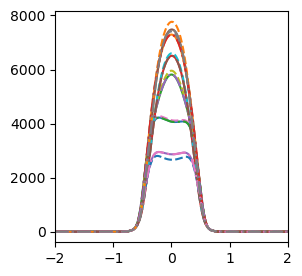

In [84]:
figure(figsize=(3,3))
plot(t,abs2.(At_final[:,:,1]))
plot(t,abs2.(At_final_cp_1em1[:,:,1]),"--")
plot(t,abs2.(At_final_cp_1em3[:,:,1]),"-.")
xlim(-2,2)
display(gcf())

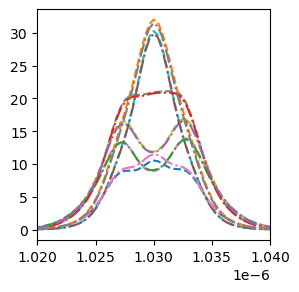

In [87]:
figure(figsize=(3,3))
plot(λ,abs2.(Aomega_final[:,:,1]),alpha=0.1)
plot(λ,abs2.(Aomega_final_cp_1em1[:,:,1]),"--")
plot(λ,abs2.(Aomega_final_cp_1em3[:,:,1]),"-.")
xlim(1020e-9,1040e-9)
display(gcf())

In [ ]:
## timing difference is ~55 min for uncompressed simulation versus 1.25 min at error 1e-3 for compressed at just six modes.

This makes it possible to consider significantly larger mode counts using CP decomposition. Below we show an example involving 10k propagation steps with 21 modes (first six GRIN mode groups). From the above smaller run, the dense case would take approximately 140 hours.

In [108]:
core_radius = 168e-6;
NA = 0.1;
num_modes = 21;
fiber_length = 1;

material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
step_fiber = GRIN(λ0, core_radius, NA);

properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=5)

x = y = properties.modes.x
modes = properties.modes.fields; 
betas = properties.beta.coefficients;
S_tensor = properties.S.values;

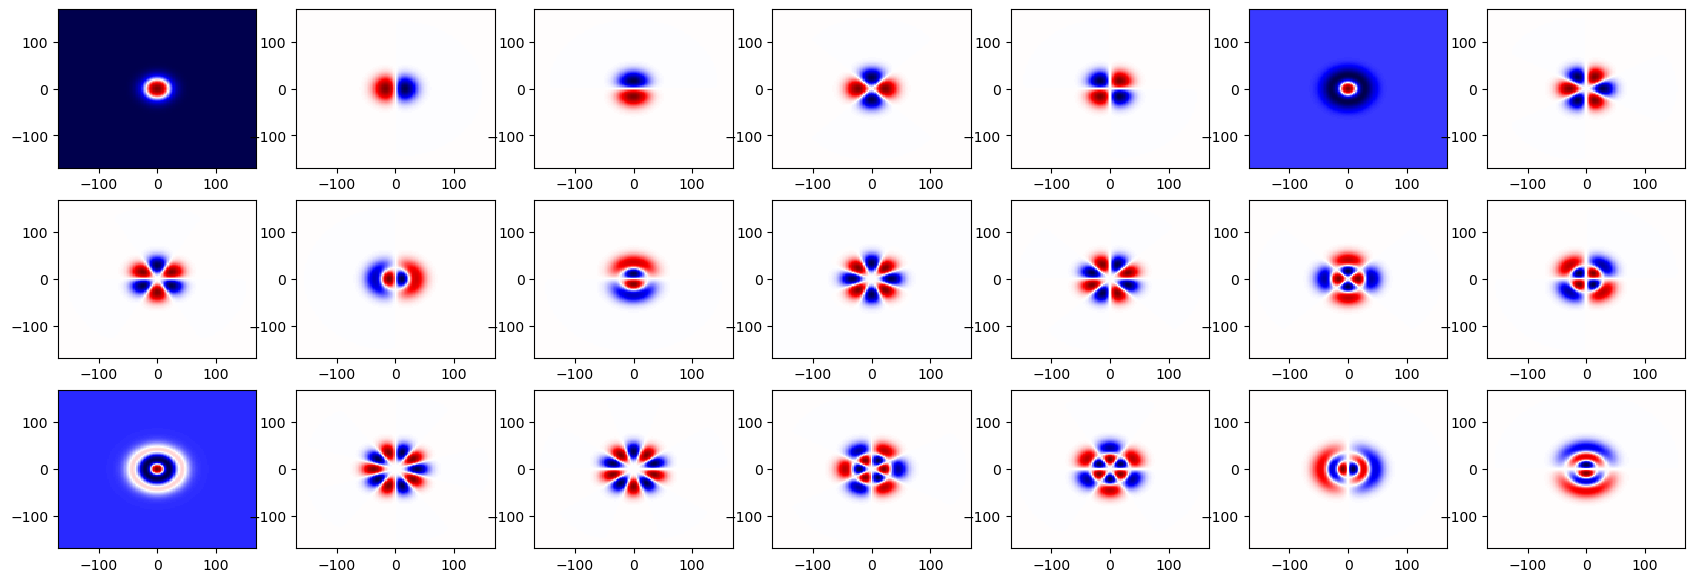

In [109]:
figure(figsize=(21,7))

for ii = 1:num_modes
    subplot(3,7,ii)
    pcolormesh(x*1e6,y*1e6,modes[:,:,ii],cmap="seismic")
end
display(gcf())

In [110]:
## Same excitation as 6 mode case, may not provide same output spectrum if other modes beyond 1:6 can be addressed by dynamics
coefficients = 1.0im*zeros(num_modes)
coefficients[1:6] .= coefficient_vector;

In [113]:
peak_power = 50000;
pulse_fwhm = 0.5;

initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = coefficients
);

In [117]:
S_compressed = cp_compress(properties.S,error=1e-3; min_rank=50,
    rank_step=25,
    max_rank=300,
    maxiter=50, #120
    tolerance=1e-6,
    ridge=1e-8,
    check_every=5);

parameters_cp = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=S_compressed,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}, Nothing}(DegreesOfFreedom(:time, :space), TimeGrid{Float64}(8192, 0.001220703125), nothing), 1.0, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([8.845117586803699e6 8.844707061595865e6 … 8.843064770184737e6 8.843064770184737e6; 4879.073158619415 4879.07513516361 … 4879.083148326786 4879.083148326786; … ; -5.0502140957779285e-8 -5.049053925462462e-8 … -5.0539336805982986e-8 -5.0539336805982986e-8; 1.5273604535327348e-10 1.506245415468805e-10 … 1.5011524111356177e-10 1.5011524111356177e-10]), MMGNLSECPDecomposition{Float64, ComplexF64}([1.0108711056545452e9, 1.0132235137644241e9, 1.1210994485650542e9, 1.2926602043994443e9, 1.1830227438563583e9, 1.174636334181358e9, 9.170247184264033e8, 9.266251331355809e8, 1.0231580279390683e9, 1.140129768251312e

In [122]:
dz = 1e-4;
solution_cp = solve_mmgnlse(initial_field, parameters_cp, dz);

In [123]:
At_final_cp = get_temporal_field(solution_cp)
Aomega_final_cp = get_spectral_field(solution_cp)

8192×21×1 Array{ComplexF64, 3}:
[:, :, 1] =
          0.0+0.0im          …  -3.46945e-18+0.0im
          0.0-2.22045e-16im              0.0+0.0im
          0.0+0.0im              1.73472e-18+0.0im
          0.0-4.44089e-16im              0.0+0.0im
  2.22045e-16+2.22045e-16im              0.0+0.0im
 -2.22045e-16+0.0im          …           0.0-6.93889e-18im
  4.44089e-16-2.22045e-16im      8.67362e-19+0.0im
 -4.44089e-16-5.55112e-17im       1.0842e-19+6.93889e-18im
 -4.44089e-16-1.80411e-16im      6.50521e-19+0.0im
          0.0-5.55112e-17im     -8.67362e-19+0.0im
             ⋮               ⋱              ⋮
  4.44089e-16+2.22045e-16im              0.0+6.93889e-18im
 -4.44089e-16+3.03577e-17im      3.46945e-18+0.0im
  2.22045e-16-1.38778e-16im  …  -1.30104e-18+0.0im
 -2.22045e-16-4.44089e-16im       2.1684e-18-6.93889e-18im
          0.0+1.11022e-16im     -4.33681e-18+6.93889e-18im
 -1.11022e-16+1.11022e-16im      3.46945e-18+0.0im
  2.22045e-16+1.11022e-16im     -4.33681e-18+6.93889e-

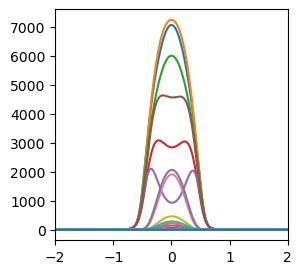

In [124]:
figure(figsize=(3,3))
plot(t,abs2.(At_final_cp[:,:,1]))
xlim(-2,2)
display(gcf())